In [1]:
from pathlib import Path

from config import PLOTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [2]:
from core.dgp import DGP_EXAMPLES, ARGARCHProcess


DGP_EXAMPLES["ar_garch"]=lambda: ARGARCHProcess()


In [3]:
# name : (dgp_names, model_short_names)
scenarios = {
    "tails_hac": (
        ["iid_t6"],
        ["iid_student_t", "hac"],
    ),
    "skew_hac": (
        ["iid_skewt60_m05", "iid_skewt6_m05"],
        ["iid_nonnormal", "hac"],
    ),
    "serial_hac": (
        ["ar1_06_normal", "ar1_m06_normal"],
        ["ar1_normal", "hac"],
    ),
    "hetero_tails_hac": (
        ["garch_normal"],
        ["garch11", "hac"],
    ),
    "serial_hetero_hac": (
        ["ar_garch"],
        ["ar1_nonnormal", "hac"],
    ),
}

parameters = {
    "n_sim": [1_000, 10_000, 30_000],
    "T":     [100, 500, 2_000],
}

In [4]:
N_SIM  = 30_000
N_JOBS = 8
param_name = "T"
param_values = parameters[param_name]

experiments = {
    "tails_hac": ExperimentSpec(
        scenario   = scenarios["tails_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "skew_hac": ExperimentSpec(
        scenario   = scenarios["skew_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "serial_hac": ExperimentSpec(
        scenario   = scenarios["serial_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
    "hetero_tails_hac": ExperimentSpec(
        scenario   = scenarios["hetero_tails_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        th_moments = True,
        n_jobs = N_JOBS,
    ),
    "serial_hetero_hac": ExperimentSpec(
        scenario   = scenarios["serial_hetero_hac"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

In [5]:
run_selected_configs(
    experiments,
    selected_experiments=[
        "tails_hac",
        "skew_hac",
        "serial_hac",
        "hetero_tails_hac",
        "serial_hetero_hac",
    ],
)


  Experiment: tails_hac
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)

  Experiment: skew_hac
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)

  Experiment: serial_hac
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)

  Experiment: hetero_tails_hac
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE

  Experiment: serial_hetero_hac
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)


In [6]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,
                       log=True,
                       xticks=param_values)
folder = PLOTS_DIR / "hac"

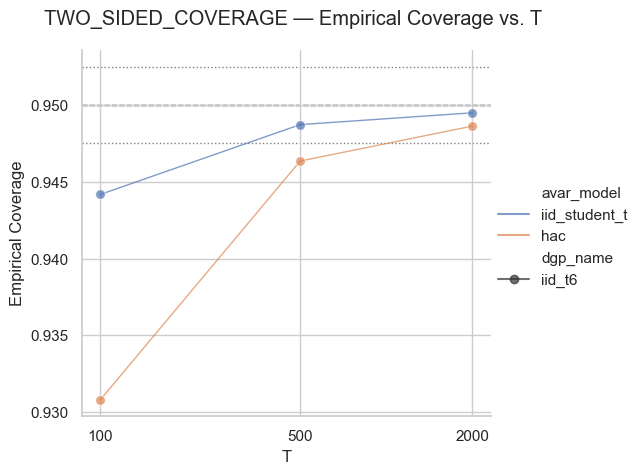

In [7]:
run_analysis(experiments, "tails_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs)

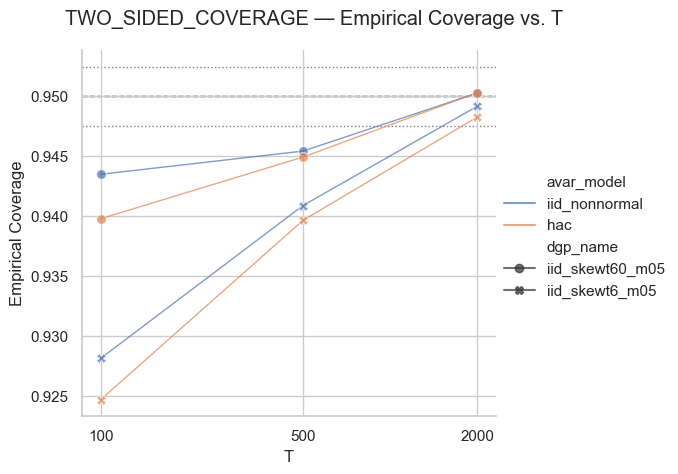

In [8]:
run_analysis(experiments, "skew_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(markers=['o', 'X']))

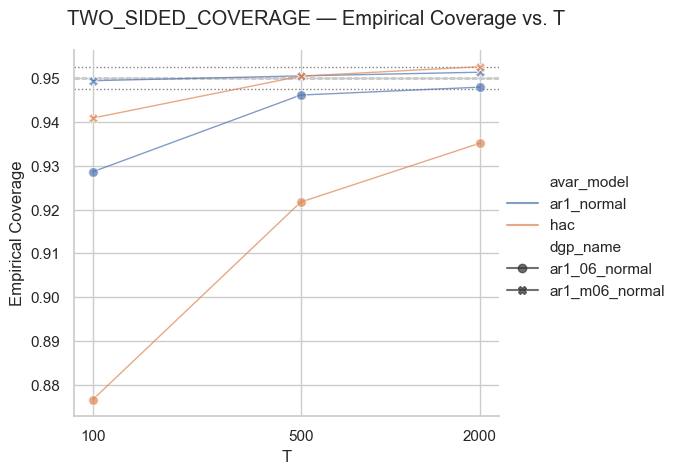

In [9]:
run_analysis(experiments, "serial_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(markers=['o', 'X']))

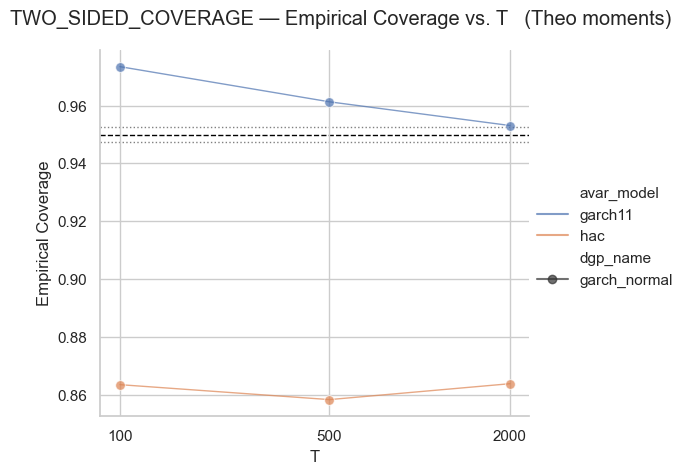

In [10]:
run_analysis(experiments, "hetero_tails_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs)

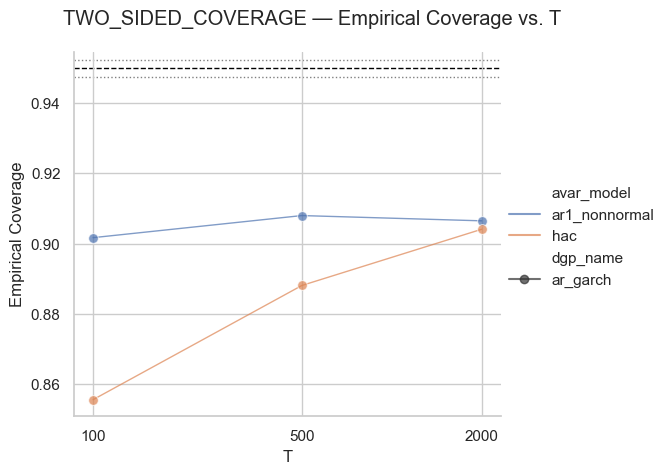

In [11]:
run_analysis(experiments, "serial_hetero_hac", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs)